In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report


In [2]:
# 🧱 Step 1 — Load and Clean Data
# Load dataset
df = pd.read_parquet("D:\LPA_MTech_Project\Enriched_Datasets\SupremeCourt_Combined_2020_2025_enriched.parquet")

# Keep only rows with labels
df = df.dropna(subset=['verdict_label']).copy()

# Basic text cleaning
df['clean_text'] = (
    df['text'].astype(str)
    .str.replace(r'\s+', ' ', regex=True)
    .str.lower()
)

# Select key features
text_col = 'clean_text'
num_cols = ['bench_size', 'sentiment_score', 'num_citations',
            'pet_vs_resp_ratio', 'num_unique_acts']
cat_col = 'case_type'
target_col = 'verdict_label'


In [3]:
# 🧮 Step 2 — Encode Case Type + Scale Numerics
# One-hot encode case_type
df = pd.get_dummies(df, columns=[cat_col], drop_first=True)

# Numeric features
X_num = df[num_cols].fillna(0).values
scaler = StandardScaler()
X_num = scaler.fit_transform(X_num)

# Case type one-hot features
X_cat = df.filter(like='case_type_').values


In [4]:
# 🧠 Step 3 — Text Features (TF-IDF + SVD)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words='english')
X_text_tfidf = tfidf.fit_transform(df[text_col])

# Increase SVD components from 300 → 600
svd = TruncatedSVD(n_components=600, random_state=42)
X_text_reduced = svd.fit_transform(X_text_tfidf)




In [5]:
# ⚙️ Step 4 — Combine All Features
from sklearn.preprocessing import MinMaxScaler

# Combine text + numeric + categorical
X_combined = np.hstack((X_text_reduced, X_num, X_cat))

# Normalize everything between 0–1 to balance scales
scaler_global = MinMaxScaler()
X_combined = scaler_global.fit_transform(X_combined)

y = df[target_col].astype(int).values

print("Final Feature Shape:", X_combined.shape)



Final Feature Shape: (4061, 609)


In [6]:
# 🧩 Step 5 — Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, stratify=y, random_state=42
)


In [7]:
# ⚡ Step 6 — Prepare PyTorch Data (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


Using device: cuda


In [8]:
# 🧠 Step 7 — Define Balanced PyTorch Model
class VerdictNetV21(nn.Module):
    def __init__(self, input_dim):
        super(VerdictNetV21, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

model = VerdictNetV21(X_train.shape[1]).to(device)



In [9]:
# ⚖️ Step 8 — Handle Class Imbalance
# Compute class weights
# Class weighting tuned (less aggressive)
class_weights = torch.tensor([1.5, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)



In [10]:
# 🧩 Step 9 — Train Model
epochs = 15
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(train_loader):.4f}")


Epoch 1/15 - Loss: 0.6236
Epoch 2/15 - Loss: 0.4403
Epoch 3/15 - Loss: 0.2942
Epoch 4/15 - Loss: 0.1884
Epoch 5/15 - Loss: 0.1360
Epoch 6/15 - Loss: 0.0845
Epoch 7/15 - Loss: 0.0535
Epoch 8/15 - Loss: 0.0487
Epoch 9/15 - Loss: 0.0479
Epoch 10/15 - Loss: 0.0676
Epoch 11/15 - Loss: 0.0369
Epoch 12/15 - Loss: 0.0269
Epoch 13/15 - Loss: 0.0294
Epoch 14/15 - Loss: 0.0387
Epoch 15/15 - Loss: 0.0307


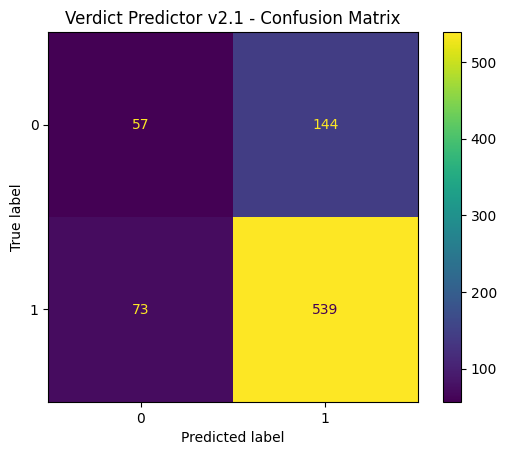

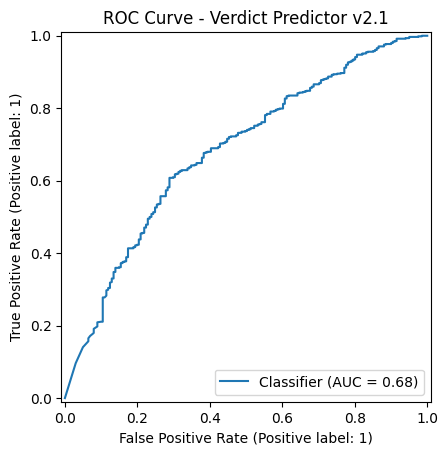

ROC AUC: 0.6820838617370663


In [11]:
# 🧪 Step 10 — Evaluate
# model.eval()
# y_pred_list = []

# with torch.no_grad():
#     for X_batch, _ in test_loader:
#         X_batch = X_batch.to(device)
#         preds = model(X_batch)
#         y_pred = torch.argmax(preds, dim=1)
#         y_pred_list.extend(y_pred.cpu().numpy())

# acc = accuracy_score(y_test, y_pred_list)
# print("\nTest Accuracy:", acc)
# print("\nClassification Report:\n", classification_report(y_test, y_pred_list))

from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    probs = model(X_test_tensor.to(device)).softmax(dim=1).cpu().numpy()
    preds = np.argmax(probs, axis=1)

ConfusionMatrixDisplay.from_predictions(y_test, preds)
plt.title("Verdict Predictor v2.1 - Confusion Matrix")
plt.show()

RocCurveDisplay.from_predictions(y_test, probs[:,1])
plt.title("ROC Curve - Verdict Predictor v2.1")
plt.show()

print("ROC AUC:", roc_auc_score(y_test, probs[:,1]))



In [12]:
# 💾 Step 11 — Save Artifacts
torch.save(model.state_dict(), "My_Models/verdict_predictor_v21.pt")

import joblib
joblib.dump(tfidf, "My_Models/tfidf_vectorizer_v21.pkl")
joblib.dump(svd, "My_Models/svd_model_v21.pkl")
joblib.dump(scaler_global, "My_Models/global_scaler_v21.pkl")



['My_Models/global_scaler_v21.pkl']